# Posição dos clientes suspensos — 16/09/2026

Análise da planilha `Clientes Suspensos e Tratados por CS - Posição em 16-09-2026.xlsx`.

**O que queremos decidir:** onde o time de CS está conseguindo recuperar dinheiro, onde travou, e o que precisa de decisão agora.

Três frentes, que são coisas diferentes e não devem ser somadas ingenuamente:

| aba | o que é |
|---|---|
| **Inadimplencia** | cliente devendo, contrato suspenso, ainda pode voltar |
| **Churn** | cliente já pediu cancelamento — aqui o dinheiro é multa/distrato, não mensalidade |
| **Em_Negociacao** | suspensão comercial ou documental, sem pedido de cancelamento firme |

In [1]:
import glob, os, re
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
COR_PRIMARIA   = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE   = "#E69F00"
COR_ALERTA     = "#D55E00"
COR_OK         = "#009E73"
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=PALETA),
})

def reais(v):
    return f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

def pct(v):
    return f"{v*100:.1f}%".replace(".", ",")

## Os dados foram lidos corretamente?

Cada aba tem linhas de total acima do cabeçalho, então o `header` muda de aba para aba. Vamos carregar e conferir formato, tipos e acentuação antes de analisar qualquer coisa.

In [3]:
ARQ = glob.glob(os.path.join(r"..\..\clientes", "*.xlsx"))[0]

def carregar(aba, header):
    df = pd.read_excel(ARQ, sheet_name=aba, header=header).dropna(how="all")
    return df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]

ina = carregar("Inadimplencia", 2)
churn = carregar("Churn", 3)
neg = carregar("Em_Negociacao", 2)

print(f"Inadimplencia  {ina.shape}")
print(f"Churn          {churn.shape}")
print(f"Em_Negociacao  {neg.shape}")
ina[["Cliente", "Produto", "R$ Contrato", "Total Dívida (R$)", "Dias de Atraso Atual"]].head(3)

Inadimplencia  (26, 24)
Churn          (28, 11)
Em_Negociacao  (10, 10)


,Cliente,Produto,R$ Contrato,Total Dívida (R$),Dias de Atraso Atual
0,ALZIR PIMENTEL AGUIAR NETO IE: 19.569.743-0,AGRIMANAGER ERP,8758.44,43792.20,219
1,MARCOS AURELIO SINOPOLI,AGRIMANAGER ERP,3380.27,13521.08,96
2,JOAO BATISTA CONSENTINI FILHO I.E.11.457.541-0,AGRIMANAGER ERP,4204.55,10688.86,160


In [4]:
print("Tipos das colunas de dinheiro e prazo (Inadimplencia):")
print(ina[["R$ Contrato", "(R$) Débito faturado", "(R$) Valor represado",
           "Total Dívida (R$)", "Dias de Atraso Atual", "Data suspensão"]].dtypes.to_frame("tipo"))
print()
print("Valor (R$) em Churn:", churn["Valor (R$)"].dtype, "| Em_Negociacao:", neg["Valor (R$)"].dtype)

Tipos das colunas de dinheiro e prazo (Inadimplencia):
                                tipo
R$ Contrato                  float64
(R$) Débito faturado         float64
(R$) Valor represado         float64
Total Dívida (R$)            float64
Dias de Atraso Atual           int64
Data suspensão        datetime64[us]

Valor (R$) em Churn: float64 | Em_Negociacao: float64


**Resultado:** leitura correta. As 26/28/10 linhas batem com os contadores que a própria planilha traz acima do cabeçalho, a acentuação saiu limpa, os valores estão numéricos e a data de suspensão veio como data. Pode analisar.

## Quanto dinheiro está em jogo — e por que existem dois números?

A aba Inadimplencia traz duas colunas de dinheiro que medem coisas diferentes. Antes de calcular qualquer percentual de recuperação, precisamos deixar claro qual é qual, senão o indicador engana.

In [5]:
bases = pd.DataFrame({
    "Inadimplencia": [ina["R$ Contrato"].sum(), ina["(R$) Débito faturado"].sum(),
                      ina["(R$) Valor represado"].sum(), ina["Total Dívida (R$)"].sum()],
    "Churn":         [churn["Valor (R$)"].sum(), None, None, None],
    "Em_Negociacao": [neg["Valor (R$)"].sum(), None, None, None],
}, index=["Valor de contrato", "Débito faturado", "Valor represado", "Total da dívida"])

bases.map(lambda v: reais(v) if pd.notna(v) else "—")

,Inadimplencia,Churn,Em_Negociacao
Valor de contrato,"R$ 59.016,38","R$ 44.028,56","R$ 13.252,73"
Débito faturado,"R$ 105.157,81",—,—
Valor represado,"R$ 223.122,45",—,—
Total da dívida,"R$ 328.280,26",—,—


**Resultado:** são duas histórias, não uma.

- **Valor de contrato (R$ 59.016 na inadimplência)** é o tamanho da carteira suspensa — quanto de receita recorrente está parada. É a base que as abas Resumo e Geral usam, e é o número que a diretoria já viu.
- **Total da dívida (R$ 328.280)** é o dinheiro efetivamente em aberto. Ele se divide em **débito faturado (R$ 105.158)**, que é nota emitida e cobrável hoje, e **valor represado (R$ 223.122)**, que é parcela segurada, ainda não faturada.

Os dois indicadores vão andar lado a lado no resto da análise. O represado é o mais importante e o menos discutido: são **68% de toda a dívida** e é justamente onde os acordos não estão chegando.

## Inadimplência: o que a coluna OBS. CS está dizendo?

A `OBS. CS` é texto livre escrito pelo time. Antes de classificar, vale ler as 26 anotações inteiras — é onde está a informação de quem pagou e quem sumiu.

In [6]:
for _, r in ina.sort_values("Total Dívida (R$)", ascending=False).iterrows():
    obs = " ".join(str(r["OBS. CS"]).split())
    print(f"{reais(r['Total Dívida (R$)']):>16} | {r['Cliente'][:34]:<34} | {obs[:95]}")

    R$ 58.075,29 | PETRAS DE LIMA TELLES I.E 153.832. | Sem retorno nas tentativas de contato com a cliente.
    R$ 43.792,20 | ALZIR PIMENTEL AGUIAR NETO IE: 19. | Sem retorno nas tentativas de contato com a cliente.
    R$ 35.736,48 | PEDRO HENRIQUE PINTO FADEL IE: 950 | Em negociação, cliente não concorda com o valor do débito.
    R$ 24.097,17 | TELLUS AGROPECUARIA LTDA           | Sem retorno nas tentativas de contato com a cliente.
    R$ 20.862,90 | LUIZ MOREIRA ROCHA                 | Pgto entrada realizado, restante será pago ainda hoje
    R$ 16.658,51 | CHRISTOPHER TERRENGUI IE 138736561 | Sem retorno nas tentativas de contato com a cliente.
    R$ 15.927,50 | FYLLIPE CARVALHO FREITAS BARROS    | Sem retorno do cliente nas tentativas de contato
    R$ 15.000,00 | SILVANO ROGER DA SILVA             | Sem retorno do cliente (3x)
    R$ 13.859,02 | FALCON AGRICOLA LTDA               | Cliente solicitou cancelamento por email ontem.
    R$ 13.521,08 | MARCOS AURELIO SINOPOLI    

**Resultado:** a leitura das anotações revela três coisas.

1. Há pouquíssimos pagamentos: quatro anotações falam em pago (`Pagou`, `Pago`, `Pgto entrada realizado`) e três falam em pagamento com data marcada.
2. **A dívida está concentrada em quem não responde.** Os quatro maiores devedores — que sozinhos somam mais da metade do total — estão todos como "sem retorno nas tentativas de contato".
3. Duas dimensões se misturam no mesmo campo: se o cliente **pagou** e se o cliente **responde**. `Cliente solicitou churn para projetos e sumiu` é as duas coisas. Classificar num eixo só perderia informação, então vamos separar.

### Classificando cada cliente: pagou? e responde?

Duas classificações independentes sobre o mesmo texto. Como são só 26 casos e o resultado vai para a diretoria, a regra é explícita e a tabela completa fica visível para conferência.

In [7]:
def situacao_pgto(t):
    t = str(t).lower()
    if "pgto integral das pendencias" in t or "entrada realizado" in t:
        return "Pago parcial"
    if re.search(r"\bpagou\b|\bpago\b", t):
        return "Pago integral"
    if "previsto" in t or "previsão de pgto" in t or "aguardando comprovante" in t:
        return "Pagamento agendado"
    if "negociação" in t or "em análise" in t:
        return "Em tratativa"
    if "cancelamento" in t or "churn" in t:
        return "Pediu cancelamento"
    return "Sem pagamento"

def responde(t):
    t = str(t).lower()
    sinais = ["sem retorno", "não atendem", "sumiu", "empresa fechou"]
    return "Não responde" if any(s in t for s in sinais) else "Responde"

ina["Situação pgto"] = ina["OBS. CS"].map(situacao_pgto)
ina["Contato"] = ina["OBS. CS"].map(responde)

# Posição da coordenação em 16/09, mais recente que a anotação da planilha:
# o valor cheio da dívida foi negociado e o pagamento já começou a entrar.
ina.loc[ina["Cliente"].str.strip() == "LUIZ MOREIRA ROCHA", "Situação pgto"] = "Negociado integral"

ina[["Cliente", "Situação pgto", "Contato", "OBS. CS"]].assign(
    **{"OBS. CS": ina["OBS. CS"].map(lambda t: " ".join(str(t).split())[:60])}
).sort_values(["Situação pgto", "Contato"])

,Cliente,Situação pgto,Contato,OBS. CS
5,PEDRO HENRIQUE PINTO FADEL IE: 95045009-66,Em tratativa,Responde,"Em negociação, cliente não concorda com o valo..."
9,PABLO RAFAEL SCNHEIDER,Em tratativa,Responde,Esse cliente é que o contrato deveria ser cobr...
20,JOSE ROSA DOS SANTOS,Em tratativa,Responde,Em negociação
6,LUIZ MOREIRA ROCHA,Negociado integral,Responde,"Pgto entrada realizado, restante será pago ain..."
3,VITOR MARCIO DUMONCEL E OUTROS IE: 13.890.735-8,Pagamento agendado,Responde,Pgto previsto dia 21/09
13,JOAO EVERTON PAULINO RAMOS ALVES - IE 00244869...,Pagamento agendado,Responde,Previsão de pgto 18/09
25,MOACYR BRUNETTA,Pagamento agendado,Responde,Financeiro enviou dados para pagamento via PIX...
8,PAULO MASSAYOSHI MIZOTE,Pago integral,Responde,Pagou
10,JUAREZ CARLOS SILVA FILHO,Pago integral,Responde,Pago
11,ANA PAULA BANDEIRA DE LIMA,Pago integral,Responde,Pago


**Resultado:** a classificação bate com o texto nas 26 linhas. O retrato é duro: **13 dos 26 clientes estão como "sem pagamento e sem responder"** — metade da carteira inadimplente é silêncio, não negociação difícil. Só 3 clientes aparecem como pagos integralmente.

## Quanto foi recuperado?

A planilha não tem coluna de "valor pago", então o valor recuperado sai do texto da CS somado à posição da coordenação. Duas regras valem aqui:

- **A conta é sempre sobre a dívida cheia** (débito faturado + valor represado), a mesma base usada para medir o que está em aberto. Medir o recuperado pelo valor de contrato e o não recuperado pela dívida compararia coisas diferentes.
- **Promessa firme conta como previamente recuperado**, em faixa própria. Cliente com valor negociado e data marcada não está no mesmo lugar de quem não responde.

### Os dois casos que exigem nota

**Luiz Moreira Rocha — R\$ 20.862,90, recebimento em curso.** A negociação foi fechada à vista, via PIX, e subiu para o financeiro. Por motivo que não ficou claro para a operação, o financeiro ofertou parcelamento ao cliente, que pagou a primeira parcela. Logo em seguida o cliente procurou a Amanda dizendo que queria quitar tudo; o restante foi subido para ele e estamos aguardando o comprovante. Por isso o valor entra integralmente: o acordo é do valor cheio, e a divisão foi decisão interna, não do cliente.

**Theodoro Ricardo de Andrade — R\$ 1.700 recuperados, cliente perdido.** A cliente havia solicitado suspensão do contrato. Quando a CS entrou em contato para cobrar o que estava em aberto, o financeiro informou que os valores do período de suspensão deveriam ser cobrados. A conversa acabou puxada para o critério de implantação não finalizada, que não era o assunto em pauta, e nenhuma abertura foi concedida à cliente. Ela pagou apenas as pendências faturadas, recusou os represados, pediu cancelamento e sinalizou que trataria o restante judicialmente. **Perdemos MRR de R\$ 1.700.**

> Nota de dado, para acerto na origem: a coluna `R$ Contrato` da planilha registra R\$ 850,00 para este contrato, metade do MRR informado pela coordenação. Vale conferir qual dos dois é o valor correto antes de consolidar em indicador.

In [8]:
def faixa_recup(r):
    if r["Situação pgto"] == "Pago integral":
        return "Recuperado"
    if r["Situação pgto"] == "Pago parcial":
        return "Recuperado em parte"
    if r["Situação pgto"] in ("Negociado integral", "Pagamento agendado"):
        return "Previamente recuperado"
    return "Não recuperado"

def valor_recup(r):
    f = r["Faixa"]
    if f == "Recuperado":
        return r["Total Dívida (R$)"]
    if f == "Recuperado em parte":
        return r["(R$) Débito faturado"]
    if f == "Previamente recuperado":
        return r["Total Dívida (R$)"]
    return 0.0

ina["Faixa"] = ina.apply(faixa_recup, axis=1)
ina["Recuperado (R$)"] = ina.apply(valor_recup, axis=1)
ina["Em aberto (R$)"] = ina["Total Dívida (R$)"] - ina["Recuperado (R$)"]

ina.loc[ina["Recuperado (R$)"] > 0,
        ["Cliente", "Faixa", "(R$) Débito faturado", "(R$) Valor represado",
         "Recuperado (R$)", "Em aberto (R$)"]] \
   .sort_values("Recuperado (R$)", ascending=False)

,Cliente,Faixa,(R$) Débito faturado,(R$) Valor represado,Recuperado (R$),Em aberto (R$)
6,LUIZ MOREIRA ROCHA,Previamente recuperado,20862.90,0.0,20862.90,0.0
3,VITOR MARCIO DUMONCEL E OUTROS IE: 13.890.735-8,Previamente recuperado,0.00,9753.2,9753.20,0.0
25,MOACYR BRUNETTA,Previamente recuperado,2797.30,0.0,2797.30,0.0
10,JUAREZ CARLOS SILVA FILHO,Recuperado,2600.00,0.0,2600.00,0.0
11,ANA PAULA BANDEIRA DE LIMA,Recuperado,2531.68,0.0,2531.68,0.0
8,PAULO MASSAYOSHI MIZOTE,Recuperado,2523.84,0.0,2523.84,0.0
18,THEODORO RICARDO DE ANDRADE,Recuperado em parte,1700.00,4250.0,1700.00,4250.0
13,JOAO EVERTON PAULINO RAMOS ALVES - IE 00244869...,Previamente recuperado,1381.31,0.0,1381.31,0.0


In [9]:
n = len(ina)
tot_div, tot_ctr = ina["Total Dívida (R$)"].sum(), ina["R$ Contrato"].sum()

fx = (ina.groupby("Faixa").agg(**{
        "Contratos": ("Cliente", "size"),
        "Valor recuperado": ("Recuperado (R$)", "sum"),
        "Dívida da faixa": ("Total Dívida (R$)", "sum"),
      })
      .reindex(["Recuperado", "Previamente recuperado", "Recuperado em parte", "Não recuperado"]))
fx["% da dívida total"] = (fx["Valor recuperado"] / tot_div).map(pct)
for c in ["Valor recuperado", "Dívida da faixa"]:
    fx[c] = fx[c].map(reais)
print(fx.to_string())

rec_div = ina["Recuperado (R$)"].sum()
rec_ctr = ina.loc[ina["Recuperado (R$)"] > 0, "R$ Contrato"].sum()
n_rec = (ina["Recuperado (R$)"] > 0).sum()
print()
print(pd.DataFrame([
    ["Contratos com recuperação", f"{n_rec} de {n}", pct(n_rec / n)],
    ["Base: dívida total",  f"{reais(rec_div)} de {reais(tot_div)}", pct(rec_div / tot_div)],
    ["Base: valor de contrato", f"{reais(rec_ctr)} de {reais(tot_ctr)}", pct(rec_ctr / tot_ctr)],
], columns=["Base de medição", "Recuperado", "% recuperado"]).to_string(index=False))

                        Contratos Valor recuperado Dívida da faixa % da dívida total
Faixa                                                                               
Recuperado                      3      R$ 7.655,52     R$ 7.655,52              2,3%
Previamente recuperado          4     R$ 34.794,71    R$ 34.794,71             10,6%
Recuperado em parte             1      R$ 1.700,00     R$ 5.950,00              0,5%
Não recuperado                 18          R$ 0,00   R$ 279.880,03              0,0%

          Base de medição                    Recuperado % recuperado
Contratos com recuperação                       8 de 26        30,8%
       Base: dívida total R$ 44.150,23 de R$ 328.280,26        13,4%
  Base: valor de contrato  R$ 12.529,28 de R$ 59.016,38        21,2%


**Resultado:** contando as promessas firmes, a recuperação chega a **R\$ 44.150,23, ou 13,4% da dívida** (21,2% da carteira), em 8 dos 26 contratos.

A composição importa mais que o total:

- **Caixa confirmado: R\$ 9.355,52.** Três contratos quitados (R\$ 7.655,52) mais a parte faturada paga pelo Theodoro (R\$ 1.700).
- **Previamente recuperado: R\$ 34.794,71**, quase quatro vezes o confirmado. É o Luiz Moreira Rocha com R\$ 20.862,90 de valor cheio negociado e recebimento em curso, mais três com data marcada: Vitor Marcio Dumoncel (21/09), João Everton Paulino (18/09) e Moacyr Brunetta, via PIX.

Duas ressalvas que continuam valendo:

- **Isto não é a taxa de recuperação do time.** A planilha lista quem *continua* suspenso; quem pagou e voltou a ser atendido já saiu dela.
- **Previamente recuperado não é caixa.** São R\$ 34.794,71 contratados, não compensados. A conversão dessa faixa é o indicador a acompanhar, porque é ela que sustenta a diferença entre 2,8% e 13,4%.

### O padrão que os dois casos revelam

Os relatos do Luiz Moreira Rocha e do Theodoro apontam para o mesmo lugar, e não é o cliente: **nos dois, a negociação foi conduzida pela CS e desarranjada na etapa do financeiro.** No primeiro, um acordo à vista virou parcelamento sem que a operação entendesse o motivo, e o cliente teve que pedir de novo para pagar tudo. No segundo, a recusa de qualquer abertura sobre o período suspenso, somada à entrada de um critério fora de pauta, custou o cliente e R\$ 1.700 de MRR.

[Provável] O gargalo não está no esforço de cobrança, e sim na ausência de um interlocutor único que conduza a negociação de ponta a ponta, com alçada combinada com o financeiro antes de falar com o cliente.

### Como fica o funil completo

Com as faixas de recuperação definidas, vale ver a distribuição por situação de pagamento para saber onde está o dinheiro que não se move.

In [10]:
funil = (ina.groupby("Situação pgto")
            .agg(**{"Contratos": ("Cliente", "size"),
                    "Dívida (R$)": ("Total Dívida (R$)", "sum"),
                    "Contrato (R$)": ("R$ Contrato", "sum")})
            .sort_values("Dívida (R$)", ascending=False))
funil["% da dívida"] = (funil["Dívida (R$)"] / tot_div).map(pct)
funil["Dívida (R$)"] = funil["Dívida (R$)"].map(reais)
funil["Contrato (R$)"] = funil["Contrato (R$)"].map(reais)
funil

,Contratos,Dívida (R$),Contrato (R$),% da dívida
Situação pgto,,,,
Sem pagamento,13,"R$ 211.538,67","R$ 38.543,43","64,4%"
Em tratativa,3,"R$ 45.482,34","R$ 4.863,67","13,9%"
Pediu cancelamento,2,"R$ 22.859,02","R$ 3.080,00","7,0%"
Negociado integral,1,"R$ 20.862,90","R$ 2.500,00","6,4%"
Pagamento agendado,3,"R$ 13.931,81","R$ 6.702,36","4,2%"
Pago integral,3,"R$ 7.655,52","R$ 2.476,92","2,3%"
Pago parcial,1,"R$ 5.950,00","R$ 850,00","1,8%"


In [11]:
aberto = tot_div - rec_div
# represado que segue em aberto: o de quem nada pagou, mais o saldo recusado pelo Theodoro
rep_aberto = ina.loc[ina["Faixa"].isin(["Não recuperado", "Recuperado em parte"]),
                     "(R$) Valor represado"].sum()
caixa = ina.loc[ina["Faixa"].isin(["Recuperado", "Recuperado em parte"]), "Recuperado (R$)"].sum()
prev = ina.loc[ina["Faixa"] == "Previamente recuperado", "Recuperado (R$)"].sum()

print(f"Caixa confirmado       {reais(caixa):>16}   {pct(caixa/tot_div):>6}")
print(f"Previamente recuperado {reais(prev):>16}   {pct(prev/tot_div):>6}")
print(f"{'':-<48}")
print(f"Recuperação total      {reais(rec_div):>16}   {pct(rec_div/tot_div):>6}")
print(f"Segue em aberto        {reais(aberto):>16}   {pct(aberto/tot_div):>6}")
print()
print(f"Do que segue em aberto, {reais(rep_aberto)} é valor represado ({pct(rep_aberto/aberto)}).")

Caixa confirmado            R$ 9.355,52     2,8%
Previamente recuperado     R$ 34.794,71    10,6%
------------------------------------------------
Recuperação total          R$ 44.150,23    13,4%
Segue em aberto           R$ 284.130,03    86,6%

Do que segue em aberto, R$ 213.369,25 é valor represado (75,1%).


**Resultado:** mesmo com as promessas contabilizadas, **restam R\$ 284.130,03 em aberto, 86,6% da dívida**, e a faixa "sem pagamento" segue sendo a maior de todas, com 13 contratos e R\$ 211.538,67.

Do que continua em aberto, **R\$ 213.369,25 é valor represado — 75,1%**. A recuperação melhorou o retrato, mas não mudou o diagnóstico: o que trava a carteira é parcela segurada em cliente que não responde.

Vale notar onde a recuperação aconteceu. Das quatro faixas com dinheiro, **só o Vitor Marcio Dumoncel tem dívida represada** (R\$ 9.753,20, com pagamento marcado para 21/09). Os outros sete contratos recuperados ou previamente recuperados têm represado zero ou, no caso do Theodoro, represado explicitamente recusado. O padrão se mantém: onde há represado, a negociação trava.

## Quantos clientes simplesmente não atendem?

A pergunta importa porque muda a natureza do trabalho: cliente que negocia duro é caso de proposta comercial; cliente que não responde é caso de negativação ou jurídico. São times e decisões diferentes.

Vamos medir tanto em número de contratos quanto em dinheiro — um cliente silencioso pequeno e um silencioso grande pesam muito diferente.

In [12]:
sem_contato = ina[ina["Contato"] == "Não responde"]
n_sc, div_sc, ctr_sc = len(sem_contato), sem_contato["Total Dívida (R$)"].sum(), sem_contato["R$ Contrato"].sum()

pd.DataFrame([
    ["Contratos",              f"{n_sc} de {n}",                        pct(n_sc / n)],
    ["Base: Total da dívida",  f"{reais(div_sc)} de {reais(tot_div)}",  pct(div_sc / tot_div)],
    ["Base: Valor de contrato", f"{reais(ctr_sc)} de {reais(tot_ctr)}", pct(ctr_sc / tot_ctr)],
], columns=["Base de medição", "Não responde", "% que não atende"])

,Base de medição,Não responde,% que não atende
0,Contratos,14 de 26,"53,8%"
1,Base: Total da dívida,"R$ 220.538,67 de R$ 328.280,26","67,2%"
2,Base: Valor de contrato,"R$ 40.043,43 de R$ 59.016,38","67,9%"


In [13]:
sem_contato[["Cliente", "Produto", "Total Dívida (R$)", "Dias de Atraso Atual"]] \
    .sort_values("Total Dívida (R$)", ascending=False) \
    .assign(**{"Total Dívida (R$)": lambda d: d["Total Dívida (R$)"].map(reais)})

,Cliente,Produto,Total Dívida (R$),Dias de Atraso Atual
4,PETRAS DE LIMA TELLES I.E 153.832.963,AGRIMANAGER ERP,"R$ 58.075,29",366
0,ALZIR PIMENTEL AGUIAR NETO IE: 19.569.743-0,AGRIMANAGER ERP,"R$ 43.792,20",219
15,TELLUS AGROPECUARIA LTDA,AGRIMANAGER ERP,"R$ 24.097,17",378
14,CHRISTOPHER TERRENGUI IE 138736561,MY FARM ERP,"R$ 16.658,51",406
17,FYLLIPE CARVALHO FREITAS BARROS,MY FARM ERP,"R$ 15.927,50",278
19,SILVANO ROGER DA SILVA,MY FARM ERP,"R$ 15.000,00",333
1,MARCOS AURELIO SINOPOLI,AGRIMANAGER ERP,"R$ 13.521,08",96
2,JOAO BATISTA CONSENTINI FILHO I.E.11.457.541-0,AGRIMANAGER ERP,"R$ 10.688,86",160
24,LUIZ ESPINDULA CARDOSO NETO,MY FARM ERP,"R$ 9.000,00",60
7,NOVA FRONTEIRA AGROPECUARIA LTDA,AGRIMANAGER ERP,"R$ 4.955,97",44


In [14]:
comp = ina.groupby("Contato").agg(**{
    "Contratos": ("Cliente", "size"),
    "Dívida média": ("Total Dívida (R$)", "mean"),
    "Dívida mediana": ("Total Dívida (R$)", "median"),
    "Atraso médio (dias)": ("Dias de Atraso Atual", "mean"),
})
comp["Dívida média"] = comp["Dívida média"].map(reais)
comp["Dívida mediana"] = comp["Dívida mediana"].map(reais)
comp["Atraso médio (dias)"] = comp["Atraso médio (dias)"].round(0)
comp

,Contratos,Dívida média,Dívida mediana,Atraso médio (dias)
Contato,,,,
Não responde,14,"R$ 15.752,76","R$ 12.104,97",222.0
Responde,12,"R$ 8.978,47","R$ 4.373,65",145.0


**Resultado:** **53,8% dos contratos não atendem, e eles carregam 67,2% da dívida.** A diferença entre os dois percentuais não é ruído: a mediana da dívida de quem não responde é cerca de **três vezes** a de quem responde, e o atraso médio é mais que o dobro. Ou seja, não é só que há muitos silenciosos — é que os silenciosos são justamente os maiores e os mais antigos.

A leitura prática: **a maior parte do dinheiro parado não está numa mesa de negociação. Está sem interlocutor.** Insistir com o mesmo canal de contato não vai mudar esse número; o que muda é mudar de instrumento (negativação, jurídico, cobrança terceirizada).

## "Sem retorno" na CS quer dizer que o cliente não está pagando nada?

Vale cruzar a anotação da CS com o status da régua de cobrança (`Status CaR`). Se um cliente está marcado como "cumprindo acordo" lá e como "sem retorno" aqui, as duas coisas podem ser verdade ao mesmo tempo — e mudariam bastante a leitura.

In [15]:
cruz = pd.crosstab(ina["Status CaR"].fillna("(vazio)"), ina["Contato"])
cruz["Dívida (R$)"] = ina.groupby(ina["Status CaR"].fillna("(vazio)"))["Total Dívida (R$)"].sum().map(reais)
cruz

Contato,Não responde,Responde,Dívida (R$)
Status CaR,,,
(vazio),1,1,"R$ 11.797,30"
Cumprindo Acordo;,3,0,"R$ 68.002,14"
Inadimplência,9,10,"R$ 180.652,33"
Inadimplência - em negociação,0,1,"R$ 9.753,20"
Sem detalhe (importação),1,0,"R$ 58.075,29"


In [16]:
acordo = ina[ina["Status CaR"].fillna("").str.contains("Cumprindo Acordo")]
acordo[["Cliente", "(R$) Débito faturado", "(R$) Valor represado", "Qtde Pcs Represadas", "Dinamara"]] \
    .assign(**{"Dinamara": lambda d: d["Dinamara"].str[:58]})

,Cliente,(R$) Débito faturado,(R$) Valor represado,Qtde Pcs Represadas,Dinamara
0,ALZIR PIMENTEL AGUIAR NETO IE: 19.569.743-0,0.0,43792.20,5,"Parcelas represadas - R$ 43.792,20 (05/2026 a ..."
1,MARCOS AURELIO SINOPOLI,0.0,13521.08,4,"Parcelas represadas - R$ 13.521,08 (06/2026 a ..."
2,JOAO BATISTA CONSENTINI FILHO I.E.11.457.541-0,0.0,10688.86,2,"Parcelas represadas - R$ 10.688,86 (08/26 e 09..."


**Resultado: este é o achado mais importante da aba.** Três clientes — R$ 68.002,14, 21% de toda a dívida — estão **cumprindo acordo de renegociação** e mesmo assim aparecem como "sem retorno" para a CS.

Não há contradição: eles estão pagando à cobrança (acordo com a Averbach) e não estão falando com o time de sucesso do cliente. O detalhe que importa está na coluna da Dinamara: **o débito de R$ 68 mil que aparece aqui é 100% represado e está explicitamente "fora acordo"**. O acordo cobre o que já havia sido faturado; as parcelas seguradas durante a suspensão ficaram de fora e ninguém está negociando.

Consequência prática: esses três não são caso de negativação nem de jurídico — são caso de **fechar a ponta solta do represado antes que o acordo termine**. Se o acordo se encerrar sem isso, o cliente vai entender que quitou, e a cobrança dos R$ 68 mil restantes vira um conflito novo com quem acabou de voltar a pagar.

## Por que os acordos travam: faturado contra represado

A suspeita que vem da leitura das anotações é que se consegue cobrar o que foi faturado, mas não o que ficou represado. Vale testar — separando os clientes que têm valor represado dos que não têm.

In [17]:
ina["Tem represado"] = ina["(R$) Valor represado"] > 0
teste = ina.groupby("Tem represado").agg(**{
    "Contratos": ("Cliente", "size"),
    "Pagaram algo": ("Recuperado (R$)", lambda s: (s > 0).sum()),
    "Dívida (R$)": ("Total Dívida (R$)", "sum"),
})
teste["% que pagou algo"] = (teste["Pagaram algo"] / teste["Contratos"]).map(pct)
teste["Dívida (R$)"] = teste["Dívida (R$)"].map(reais)
teste.index = ["Sem valor represado", "Com valor represado"]
teste

,Contratos,Pagaram algo,Dívida (R$),% que pagou algo
Sem valor represado,10,6,"R$ 50.731,29","60,0%"
Com valor represado,16,2,"R$ 277.548,97","12,5%"


In [18]:
conf = ina.groupby("Tem represado").agg(**{
    "Dívida mediana": ("Total Dívida (R$)", "median"),
    "Atraso mediano (dias)": ("Dias de Atraso Atual", "median"),
})
conf["Dívida mediana"] = conf["Dívida mediana"].map(reais)
conf.index = ["Sem valor represado", "Com valor represado"]
print(conf.to_string())
print()
print("O único cliente COM represado que pagou algo:")
alvo = ina[(ina["Tem represado"]) & (ina["Recuperado (R$)"] > 0)]
for _, r in alvo.iterrows():
    print(f"  {r['Cliente']} — pagou {reais(r['Recuperado (R$)'])} (faturado), "
          f"deixou {reais(r['(R$) Valor represado'])} (represado)")

                    Dívida mediana  Atraso mediano (dias)
Sem valor represado    R$ 2.565,84                   62.0
Com valor represado   R$ 13.690,05                  248.5

O único cliente COM represado que pagou algo:
  VITOR MARCIO DUMONCEL E OUTROS IE: 13.890.735-8 — pagou R$ 9.753,20 (faturado), deixou R$ 9.753,20 (represado)
  THEODORO RICARDO DE ANDRADE — pagou R$ 1.700,00 (faturado), deixou R$ 4.250,00 (represado)


**Resultado, com a ressalva na frente:** a diferença de taxa (30% contra 6,2%) vem de bases pequenas — 10 e 16 contratos — e os dois grupos não são comparáveis: quem tem represado deve cerca de **quatro vezes mais** e está suspenso há muito mais tempo. Parte da diferença é simplesmente dívida maior e mais antiga, não o represado em si. **Só o percentual não sustenta a conclusão.**

O que sustenta é a evidência direta no texto, que independe da estatística:

- **Theodoro Ricardo de Andrade** é o único cliente com represado que pagou algo, e pagou exatamente a parte faturada. A anotação registra que ele recusou o represado, cancelou e sinalizou que vai discutir o restante judicialmente.
- **Alzir, Marcos Aurélio e João Batista** cumprem acordo, e a planilha diz com todas as letras que as parcelas represadas estão "fora acordo".

Os dois fatos apontam para o mesmo ponto: **o represado não entra em acordo nenhum.** Ele é o resíduo que sobra de toda negociação — e é onde estão R$ 223 mil dos R$ 328 mil.

> [Provável] O represado é um travamento estrutural, não um problema de esforço de cobrança. [Suposição] Clientes tendem a não reconhecer como devida a cobrança de um período em que ficaram sem acesso ao sistema — é literalmente o argumento do Theodoro e do Pedro Henrique.

## Onde a dívida está concentrada?

Vale ver a distribuição por cliente e por produto antes de fechar a aba.

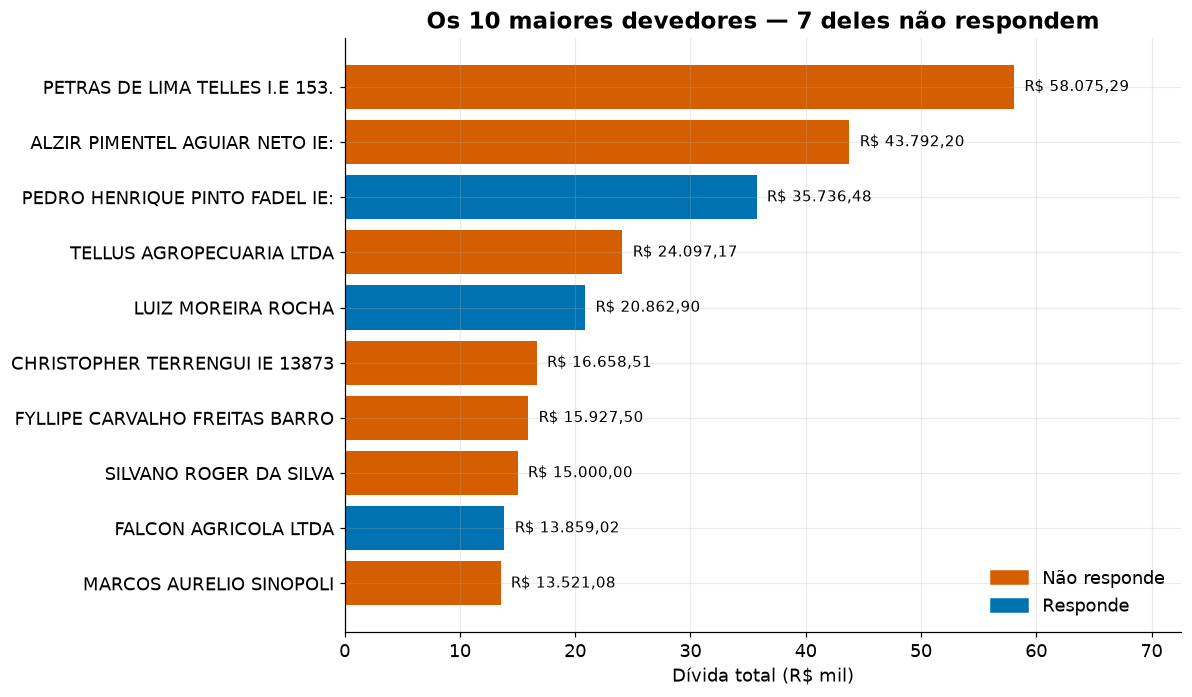

Os 10 maiores somam R$ 257.530,15 — 78,4% de toda a dívida da aba.


In [19]:
top = ina.nlargest(10, "Total Dívida (R$)")
cores = [COR_ALERTA if c == "Não responde" else COR_PRIMARIA for c in top["Contato"]]
n_mudos = (top["Contato"] == "Não responde").sum()

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(top["Cliente"].str[:30], top["Total Dívida (R$)"], color=cores)
ax.invert_yaxis()
ax.set_title(f"Os 10 maiores devedores — {n_mudos} deles não respondem")
ax.set_xlabel("Dívida total (R$ mil)")
ax.xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}")
for y, v in enumerate(top["Total Dívida (R$)"]):
    ax.text(v + 900, y, reais(v), va="center", fontsize=10)
ax.set_xlim(0, top["Total Dívida (R$)"].max() * 1.25)
ax.legend(handles=[plt.Rectangle((0,0),1,1, color=COR_ALERTA), plt.Rectangle((0,0),1,1, color=COR_PRIMARIA)],
          labels=["Não responde", "Responde"], frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

print(f"Os 10 maiores somam {reais(top['Total Dívida (R$)'].sum())} — "
      f"{pct(top['Total Dívida (R$)'].sum()/tot_div)} de toda a dívida da aba.")

**Resultado:** **10 clientes concentram 78,4% da dívida**, e 7 desses 10 não respondem. A carteira inadimplente não é um problema de 26 casos — é um problema de meia dúzia de nomes grandes e mudos, mais uma cauda pequena que em boa medida já está sendo tratada.

Isso é uma boa notícia operacional: dá para atacar quase 80% do valor com uma lista de dez nomes.

---

# Aba Churn: o que a OBS CS mostra

Aqui o cliente já pediu cancelamento. O dinheiro em jogo não é mensalidade a recuperar — é **multa de distrato e boleto em aberto**. O pedido foi analisar a `OBS CS` desta aba para ver o que se conseguiu receber.

In [20]:
print(f"Contratos em churn: {len(churn)} | Valor total: {reais(churn['Valor (R$)'].sum())}")
print(f"Linhas com OBS CS preenchida: {churn['OBS CS'].notna().sum()}")
print()
churn.loc[churn["OBS CS"].notna(), ["Cliente", "Produto", "Valor (R$)", "OBS CS", "Ação de Curadoria"]]

Contratos em churn: 28 | Valor total: R$ 44.028,56
Linhas com OBS CS preenchida: 1



,Cliente,Produto,Valor (R$),OBS CS,Ação de Curadoria
1,LUCIVAL PORTILHO ARANTES IE 29.474.545-9,AGRIMANAGER ERP,4248.62,Cliente pagou hoje dia 16/09 15mil reais.,Aguardando Pagamento Multa


In [21]:
lucival = churn[churn["Cliente"].str.contains("LUCIVAL", na=False)]
print(lucival[["Cód. Contrato", "Cliente", "Produto", "Valor (R$)", "Ação de Curadoria"]].to_string(index=False))
print()
soma_luc = lucival["Valor (R$)"].sum()
print(f"Soma dos contratos do Lucival: {reais(soma_luc)}")
print(f"Valor pago em 16/09:           {reais(15000)}")
print(f"Pago / total da aba Churn:     {pct(15000/churn['Valor (R$)'].sum())}")

Cód. Contrato                                  Cliente           Produto  Valor (R$)          Ação de Curadoria
   30006028-5 LUCIVAL PORTILHO ARANTES IE 29.474.545-9   AGRIMANAGER ERP     4248.62 Aguardando Pagamento Multa
   30006243-5 LUCIVAL PORTILHO ARANTES IE 29.474.545-9 ALIARE CLOUD - PR     1647.50 Aguardando Pagamento Multa

Soma dos contratos do Lucival: R$ 5.896,12
Valor pago em 16/09:           R$ 15.000,00
Pago / total da aba Churn:     34,1%


**Resultado:** só **1 das 28 linhas** da aba Churn tem anotação de CS, e é a única entrada de dinheiro registrada: **Lucival Portilho Arantes pagou R\$ 15.000 em 16/09**.

Três observações que mudam a leitura desse número:

1. **O Lucival aparece duas vezes na aba** — dois contratos (AgriManager e Aliare Cloud) sob a mesma inscrição estadual, somando R\$ 5.896,12 de valor de contrato. É [Provável] que o pagamento cubra os dois; a aba os conta como dois churns separados.
2. **Os R\$ 15 mil são 2,5 vezes o valor dos contratos dele.** Confirma que a coluna `Valor (R$)` desta aba é valor de contrato, não dívida — o que ele pagou inclui débito em aberto e multa de distrato. Ou seja: **não dá para medir recuperação de churn usando a coluna de valor desta aba.**
3. Esse pagamento sozinho equivale a **34% do valor de contrato de toda a aba**. Foi o maior evento de caixa do período nesta carteira.

E o alerta: a `Ação de Curadoria` dele continua como *"Aguardando Pagamento Multa"* mesmo depois do pagamento. O campo de curadoria está defasado em relação à anotação da CS.

### Em que estágio estão os 28 churns?

Se a `OBS CS` está quase toda vazia, a informação de andamento está na `Ação de Curadoria`. Vale agrupar para ver quanto está esperando dinheiro e quanto está esperando assinatura.

In [22]:
def estagio(t):
    t = str(t).lower()
    if "multa" in t and "retorno" in t:   return "Aguardando retorno do cliente sobre a multa"
    if "pagamento multa" in t:            return "Aguardando pagamento da multa"
    if "boleto" in t:                     return "Aguardando pagamento de boletos"
    if "assinatura" in t:                 return "Aguardando assinatura do distrato"
    if "negocia" in t:                    return "Em negociação"
    if "acordo" in t:                     return "Acordo de pagamento em curso"
    return "Distrato em conclusão"

churn["Estágio"] = churn["Ação de Curadoria"].map(estagio)
est = churn.groupby("Estágio").agg(**{"Contratos": ("Cliente", "size"), "Valor (R$)": ("Valor (R$)", "sum")}) \
           .sort_values("Valor (R$)", ascending=False)
est["% do valor"] = (est["Valor (R$)"] / churn["Valor (R$)"].sum()).map(pct)
est["Valor (R$)"] = est["Valor (R$)"].map(reais)
est

,Contratos,Valor (R$),% do valor
Estágio,,,
Aguardando pagamento da multa,4,"R$ 11.020,00","25,0%"
Em negociação,4,"R$ 8.917,41","20,3%"
Aguardando pagamento de boletos,6,"R$ 7.421,36","16,9%"
Distrato em conclusão,7,"R$ 5.988,40","13,6%"
Aguardando retorno do cliente sobre a multa,4,"R$ 5.525,55","12,5%"
Aguardando assinatura do distrato,2,"R$ 4.455,84","10,1%"
Acordo de pagamento em curso,1,"R$ 700,00","1,6%"


In [23]:
esperando_dinheiro = ["Aguardando pagamento da multa", "Aguardando pagamento de boletos",
                      "Aguardando retorno do cliente sobre a multa"]
mask = churn["Estágio"].isin(esperando_dinheiro)
print(f"Churns travados esperando dinheiro: {mask.sum()} de {len(churn)} contratos "
      f"({pct(mask.sum()/len(churn))}) — {reais(churn.loc[mask,'Valor (R$)'].sum())} de valor de contrato")
print()
print("Quem está na fila da multa (grupo com maior valor):")
print(churn.loc[churn["Estágio"] == "Aguardando pagamento da multa",
                ["Cliente", "Produto", "Valor (R$)"]].to_string(index=False))

Churns travados esperando dinheiro: 14 de 28 contratos (50,0%) — R$ 23.966,91 de valor de contrato

Quem está na fila da multa (grupo com maior valor):
                                 Cliente           Produto  Valor (R$)
LUCIVAL PORTILHO ARANTES IE 29.474.545-9   AGRIMANAGER ERP     4248.62
       GEMIRO CARAFINI  IE: 11.106.270-5   AGRIMANAGER ERP     2581.48
              AUGUSTO CESAR ANDRADE MAIA       MY FARM ERP     2542.40
LUCIVAL PORTILHO ARANTES IE 29.474.545-9 ALIARE CLOUD - PR     1647.50


**Resultado:** **14 dos 28 churns — exatamente metade — estão travados esperando dinheiro entrar** (multa, boleto ou retorno do cliente sobre a multa), somando 54,4% do valor da aba. Não é cancelamento concluído: é cancelamento pendurado.

E o grupo de maior valor, "aguardando pagamento da multa", tem 4 contratos — **dois dos quais são o Lucival, que já pagou**. Descontando-o, a fila real da multa são 2 contratos (Gemiro Carafini e Augusto Cesar), R\$ 5.123,88.

A conclusão de gestão aqui não é sobre o cliente, é sobre o processo: **o campo de curadoria não reflete o que a CS já sabe.** Se um pagamento de R\$ 15 mil feito hoje não muda o status do contrato, o painel de churn superestima o que está pendente — e ninguém percebe que já entrou.

---

# Aba Em_Negociacao: posição atualizada

São 10 contratos, R\$ 13.252,73 — a menor das três abas e a de melhor prognóstico: aqui não há pedido firme de cancelamento na maioria dos casos, e sim suspensão comercial ou documental.

Dois casos têm posição mais recente do que a planilha registra, informada pela coordenação em 16/09.

In [24]:
neg[["Cód. Contrato", "Cliente", "Produto", "Valor (R$)", "Ação Vertical"]] \
    .sort_values("Valor (R$)", ascending=False) \
    .assign(**{"Ação Vertical": lambda d: d["Ação Vertical"].str[:58],
               "Valor (R$)": lambda d: d["Valor (R$)"].map(reais)})

,Cód. Contrato,Cliente,Produto,Valor (R$),Ação Vertical
0,30005923-5,COOPERATIVA AGROPECUARIA PRIMAVERA COAP,MY FARM ERP,"R$ 5.946,19",Negociação e prazo de retomada
8,30004481-5,AGROPECUARIA ALVORADA LTDA,AGRIMANAGER ERP,"R$ 1.859,64",Migração AGM Myfarm | Aguardando pagamento da ...
9,30007136-5,FERNANDO VIEIRA PERES,MY FARM ERP,"R$ 1.670,87",Acionar cobrança e definir reativar x churn - ...
1,30005114-5,LISEU JOSE SCHERER - IE.13.260.772-7,MY FARM ERP,"R$ 936,91",Negociação e prazo de retomada
2,30007333-5,KNAP SOLUCOES CONTABEIS LTDA,MY FARM ERP,"R$ 705,99",Respondido essa semana - Aguardando cliente pa...
7,30005762-5,WILLIAM CARDOSO DOS SANTOS,MY FARM ERP,"R$ 500,00",Aguardando Retorno do CS
3,30005113-5,DIEGO MORA MACENA,MY FARM ERP,"R$ 493,08",Negociação e prazo de retomada
4,30005886-5,WALDYRENE BARROS SILVA,MY FARM ERP,"R$ 419,25",Status correto - Suspenso - Pendencias de Proj...
5,30002312-5,ADRIANA CRISTINA GUIZELINI,MY FARM ERP,"R$ 408,28",Negociação e prazo de retomada
6,30003798-5,JOSE WILIAN BAHDUR,MY FARM ERP,"R$ 312,52","Suspensão realizada pelo faturamento, aguardan..."


### Posição atualizada em 16/09 — Agropecuária Alvorada e KNAP

Dois contratos desta aba têm andamento mais recente do que a planilha registra. A planilha original não foi alterada; a atualização entra aqui na análise.

In [25]:
atualizacoes = {
    "30004481-5": {
        "Posição em 16/09": "Acordo fechado — aguardando pagamento da 1ª parcela",
        "Desfecho": "Retido (migrado para myFarm)",
    },
    "30007333-5": {
        "Posição em 16/09": "Pago",
        "Desfecho": "Resolvido",
    },
}

neg["Posição em 16/09"] = neg["Cód. Contrato"].map(lambda c: atualizacoes.get(c, {}).get("Posição em 16/09", "—"))
neg["Desfecho"] = neg["Cód. Contrato"].map(lambda c: atualizacoes.get(c, {}).get("Desfecho", "Em aberto"))

neg.loc[neg["Cód. Contrato"].isin(atualizacoes),
        ["Cód. Contrato", "Cliente", "Produto", "Valor (R$)", "Ação Vertical", "Posição em 16/09"]] \
    .assign(**{"Ação Vertical": lambda d: d["Ação Vertical"].str[:45],
               "Valor (R$)": lambda d: d["Valor (R$)"].map(reais)})

,Cód. Contrato,Cliente,Produto,Valor (R$),Ação Vertical,Posição em 16/09
2,30007333-5,KNAP SOLUCOES CONTABEIS LTDA,MY FARM ERP,"R$ 705,99",Respondido essa semana - Aguardando cliente p,Pago
8,30004481-5,AGROPECUARIA ALVORADA LTDA,AGRIMANAGER ERP,"R$ 1.859,64",Migração AGM Myfarm | Aguardando pagamento da,Acordo fechado — aguardando pagamento da 1ª pa...


**Agropecuária Alvorada Ltda** (contrato 30004481-5, R\$ 1.859,64) — **acordo fechado, aguardando o pagamento da primeira parcela, e o cliente foi migrado para o myFarm.**

Esse caso merece destaque por três motivos:

1. **A planilha classifica errado o desfecho.** O `Resumo da Anotação` diz *"Em processo de cancelamento"* e a `Categoria da Causa` está como Negociação/Retenção com pedido de negativação aberto desde 23/06/2025. Na prática não houve perda de cliente: houve **retenção com troca de produto**. Reportado como está, entra na conta de churn um cliente que ficou.
2. **Era o único contrato AgriManager da aba** — os outros nove são todos myFarm. Com a migração, a aba Em_Negociacao passa a ser 100% myFarm.
3. **O caso arrasta desde junho de 2025**, mais de um ano. A saída veio pela migração de produto, não pela cobrança. Vale registrar como padrão testável: cliente AGM travado por custo/estrutura pode ser retido no myFarm em vez de perdido.

**KNAP Soluções Contábeis Ltda** (contrato 30007333-5, R\$ 705,99) — **pago.** A pendência era documental: contrato em análise do Jurídico junto com o Angelo e o Julio, por ser o contrato usado pelo Jader (BPO) para atendimento de terceiros. Com o pagamento dos valores em aberto, sai da lista de suspensos. Fica em aberto se a discussão contratual do uso por BPO foi encerrada junto ou se segue separada — são coisas diferentes.

In [26]:
resolvido = neg.loc[neg["Desfecho"] == "Resolvido", "Valor (R$)"].sum()
retido = neg.loc[neg["Desfecho"] == "Retido (migrado para myFarm)", "Valor (R$)"].sum()
tot_neg = neg["Valor (R$)"].sum()

pd.DataFrame([
    ["Resolvido (KNAP, pago)", 1, reais(resolvido), pct(resolvido / tot_neg)],
    ["Retido com migração (Alvorada, 1ª parcela pendente)", 1, reais(retido), pct(retido / tot_neg)],
    ["Segue em aberto", 8, reais(tot_neg - resolvido - retido), pct((tot_neg - resolvido - retido) / tot_neg)],
], columns=["Desfecho", "Contratos", "Valor de contrato", "% da aba"])

,Desfecho,Contratos,Valor de contrato,% da aba
0,"Resolvido (KNAP, pago)",1,"R$ 705,99","5,3%"
1,"Retido com migração (Alvorada, 1ª parcela pend...",1,"R$ 1.859,64","14,0%"
2,Segue em aberto,8,"R$ 10.687,10","80,6%"


**Resultado:** com as duas atualizações, **2 dos 10 contratos da aba já têm desfecho** — um pago e um retido com migração —, e os R\$ 10.687,10 restantes seguem em aberto, concentrados na Cooperativa Primavera (R\$ 5.946,19, mais da metade). Metade da aba está na negociação de renovação anual do myFarm conduzida com a Ramona, que é um caso comercial, não de cobrança.

---

## A imagem completa: onde está o dinheiro parado

Juntando as três abas — lembrando que elas não somam na mesma moeda: a inadimplência tem dívida, as outras duas têm valor de contrato.

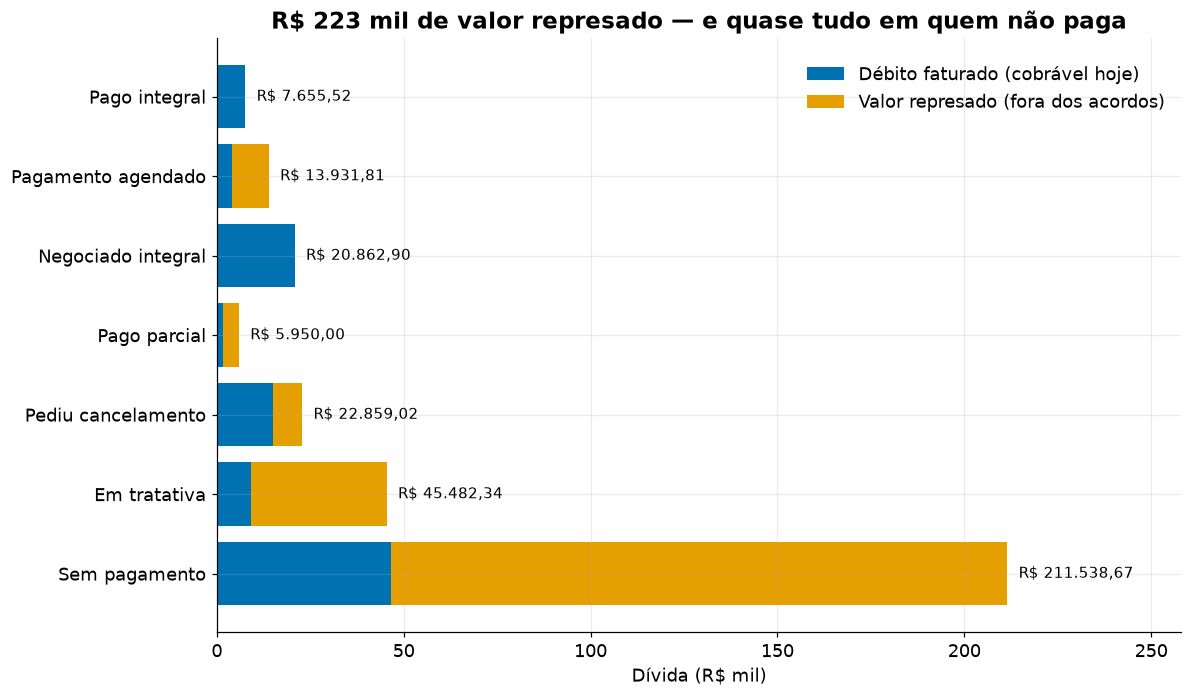

In [27]:
sit_ord = ["Sem pagamento", "Em tratativa", "Pediu cancelamento", "Pago parcial",
           "Negociado integral", "Pagamento agendado", "Pago integral"]
g = ina.groupby("Situação pgto")[["(R$) Débito faturado", "(R$) Valor represado"]].sum().reindex(sit_ord)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(g.index, g["(R$) Débito faturado"], color=COR_PRIMARIA, label="Débito faturado (cobrável hoje)")
ax.barh(g.index, g["(R$) Valor represado"], left=g["(R$) Débito faturado"],
        color=COR_DESTAQUE, label="Valor represado (fora dos acordos)")
ax.set_title("R$ 223 mil de valor represado — e quase tudo em quem não paga")
ax.set_xlabel("Dívida (R$ mil)")
ax.xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}")
for y, (f, r) in enumerate(zip(g["(R$) Débito faturado"], g["(R$) Valor represado"])):
    if f + r > 0:
        ax.text(f + r + 3000, y, reais(f + r), va="center", fontsize=10)
ax.set_xlim(0, (g.sum(axis=1).max()) * 1.22)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.0, 0.98))
plt.tight_layout()
plt.show()

**Resultado:** o gráfico resume o problema numa imagem. A faixa "sem pagamento" é a maior de todas e é majoritariamente **laranja — valor represado**. Nas faixas onde há pagamento acontecendo, o azul domina: paga-se o que foi faturado.

O represado não é uma linha contábil neutra. É o que impede o cliente de fechar a conta e voltar.

In [28]:
consolidado = pd.DataFrame([
    ["Inadimplência", len(ina), reais(ina["R$ Contrato"].sum()), reais(tot_div),
     f"{(ina['Contato']=='Não responde').sum()} não respondem ({pct((ina['Contato']=='Não responde').mean())})"],
    ["Churn", len(churn), reais(churn["Valor (R$)"].sum()), "não informada",
     f"{mask.sum()} travados esperando dinheiro ({pct(mask.mean())})"],
    ["Em negociação", len(neg), reais(tot_neg), "não informada",
     "2 com desfecho (1 pago, 1 retido)"],
], columns=["Frente", "Contratos", "Valor de contrato", "Dívida total", "Situação dominante"])
consolidado

,Frente,Contratos,Valor de contrato,Dívida total,Situação dominante
0,Inadimplência,26,"R$ 59.016,38","R$ 328.280,26","14 não respondem (53,8%)"
1,Churn,28,"R$ 44.028,56",não informada,"14 travados esperando dinheiro (50,0%)"
2,Em negociação,10,"R$ 13.252,73",não informada,"2 com desfecho (1 pago, 1 retido)"


---

## Levantamento cliente a cliente (inadimplência)

A tabela abaixo é o levantamento pedido: para cada um dos 26 contratos, o que a `OBS. CS` diz que já foi tratado, o que a régua de cobrança registra, e onde o caso está parado. Ordenada por dívida.

In [29]:
def andamento(r):
    car = str(r["Status CaR"])
    if r["Faixa"] == "Recuperado":
        return "Quitado"
    if r["Situação pgto"] == "Negociado integral":
        return "Valor cheio negociado — recebimento em curso"
    if r["Situação pgto"] == "Pagamento agendado":
        return "Pagamento com data marcada"
    if r["Situação pgto"] == "Pago parcial":
        return "Pagou o faturado e recusou o represado"
    if "Cumprindo Acordo" in car:
        return "Cumprindo acordo na cobrança — represado ficou fora"
    if r["Situação pgto"] == "Em tratativa":
        return "Negociação aberta com divergência de valor"
    if r["Situação pgto"] == "Pediu cancelamento":
        return "Pedido de cancelamento em curso"
    return "Parado — sem interlocutor"

ina["Andamento"] = ina.apply(andamento, axis=1)

levantamento = (ina.sort_values("Total Dívida (R$)", ascending=False)
    .assign(**{
        "Dívida": lambda d: d["Total Dívida (R$)"].map(reais),
        "Represado": lambda d: d["(R$) Valor represado"].map(reais),
        "Atraso": lambda d: d["Dias de Atraso Atual"].astype(str) + "d",
        "O que a CS registrou": lambda d: d["OBS. CS"].map(lambda t: " ".join(str(t).split())[:70]),
    })[["Cliente", "Produto", "Dívida", "Represado", "Atraso",
        "Faixa", "Contato", "Andamento", "O que a CS registrou"]]
    .reset_index(drop=True))

levantamento["Cliente"] = levantamento["Cliente"].str[:32]
levantamento

,Cliente,Produto,Dívida,Represado,Atraso,Faixa,Contato,Andamento,O que a CS registrou
0,PETRAS DE LIMA TELLES I.E 153.83,AGRIMANAGER ERP,"R$ 58.075,29","R$ 58.075,29",366d,Não recuperado,Não responde,Parado — sem interlocutor,Sem retorno nas tentativas de contato com a cl...
1,ALZIR PIMENTEL AGUIAR NETO IE: 1,AGRIMANAGER ERP,"R$ 43.792,20","R$ 43.792,20",219d,Não recuperado,Não responde,Cumprindo acordo na cobrança — represado ficou...,Sem retorno nas tentativas de contato com a cl...
2,PEDRO HENRIQUE PINTO FADEL IE: 9,AGRIMANAGER ERP,"R$ 35.736,48","R$ 35.736,48",194d,Não recuperado,Responde,Negociação aberta com divergência de valor,"Em negociação, cliente não concorda com o valo..."
3,TELLUS AGROPECUARIA LTDA,AGRIMANAGER ERP,"R$ 24.097,17","R$ 22.029,70",378d,Não recuperado,Não responde,Parado — sem interlocutor,Sem retorno nas tentativas de contato com a cl...
4,LUIZ MOREIRA ROCHA,MY FARM ERP,"R$ 20.862,90","R$ 0,00",64d,Previamente recuperado,Responde,Valor cheio negociado — recebimento em curso,"Pgto entrada realizado, restante será pago ain..."
5,CHRISTOPHER TERRENGUI IE 1387365,MY FARM ERP,"R$ 16.658,51","R$ 1.781,06",406d,Não recuperado,Não responde,Parado — sem interlocutor,Sem retorno nas tentativas de contato com a cl...
6,FYLLIPE CARVALHO FREITAS BARROS,MY FARM ERP,"R$ 15.927,50","R$ 6.317,50",278d,Não recuperado,Não responde,Parado — sem interlocutor,Sem retorno do cliente nas tentativas de contato
7,SILVANO ROGER DA SILVA,MY FARM ERP,"R$ 15.000,00","R$ 6.000,00",333d,Não recuperado,Não responde,Parado — sem interlocutor,Sem retorno do cliente (3x)
8,FALCON AGRICOLA LTDA,MY FARM ERP,"R$ 13.859,02","R$ 7.900,00",125d,Não recuperado,Responde,Pedido de cancelamento em curso,Cliente solicitou cancelamento por email ontem.
9,MARCOS AURELIO SINOPOLI,AGRIMANAGER ERP,"R$ 13.521,08","R$ 13.521,08",96d,Não recuperado,Não responde,Cumprindo acordo na cobrança — represado ficou...,Sem retorno nas tentativas de contato com a cl...


**Resultado:** lendo a tabela de cima para baixo, os quatro maiores casos (R\$ 58 mil, R\$ 44 mil, R\$ 36 mil, R\$ 24 mil) têm perfis muito diferentes e pedem ações diferentes:

- **Petras de Lima Telles (R\$ 58.075, 366 dias)** — regularizou o faturado com a Averbach, mas parou de responder quando se tentou negociar os represados. Não está negativado. É o maior caso da carteira e está sem dono.
- **Alzir Pimentel (R\$ 43.792, 219 dias)** — cumprindo acordo de 10x, represado de 05 a 09/2026 explicitamente fora do acordo, sem previsão de negociação.
- **Pedro Henrique Fadel (R\$ 35.736, 194 dias)** — único grande que conversa. Contesta o valor porque já tinha tentado renegociar redução antes. É uma disputa de valor, resolvível.
- **Tellus Agropecuária (R\$ 24.097, 378 dias)** — negativação liberada desde 12/2025 e três notas em processo de cancelamento. Caso mais avançado no caminho da perda.

Não há uma ação única que sirva para os quatro. O que há em comum é o represado.

### O represado é um problema de qual produto?

A tabela acima levanta uma suspeita: os maiores casos de represado puro são todos AgriManager. Vale conferir.

In [30]:
prod = ina.groupby("Produto").agg(**{
    "Contratos": ("Cliente", "size"),
    "Faturado": ("(R$) Débito faturado", "sum"),
    "Represado": ("(R$) Valor represado", "sum"),
    "Dívida": ("Total Dívida (R$)", "sum"),
})
prod["% represado"] = (prod["Represado"] / prod["Dívida"]).map(pct)
prod["Dívida média"] = (prod["Dívida"] / prod["Contratos"]).map(reais)
for c in ["Faturado", "Represado", "Dívida"]:
    prod[c] = prod[c].map(reais)
print(prod.to_string())
print()

top4 = ina.nlargest(4, "(R$) Valor represado")
print(f"Os 4 maiores represados somam {reais(top4['(R$) Valor represado'].sum())} — "
      f"{pct(top4['(R$) Valor represado'].sum()/ina['(R$) Valor represado'].sum())} de todo o represado.")
print(top4[["Cliente", "Produto", "(R$) Valor represado", "Qtde Pcs Represadas"]].to_string(index=False))

                 Contratos      Faturado      Represado         Dívida % represado  Dívida média
Produto                                                                                         
AGRIMANAGER ERP         10  R$ 11.947,28  R$ 193.596,81  R$ 205.544,09       94,2%  R$ 20.554,41
MY FARM ERP             16  R$ 93.210,53   R$ 29.525,64  R$ 122.736,17       24,1%   R$ 7.671,01

Os 4 maiores represados somam R$ 159.633,67 — 71,5% de todo o represado.
                                    Cliente         Produto  (R$) Valor represado  Qtde Pcs Represadas
      PETRAS DE LIMA TELLES I.E 153.832.963 AGRIMANAGER ERP              58075.29                   13
ALZIR PIMENTEL AGUIAR NETO IE: 19.569.743-0 AGRIMANAGER ERP              43792.20                    5
 PEDRO HENRIQUE PINTO FADEL IE: 95045009-66 AGRIMANAGER ERP              35736.48                    8
                   TELLUS AGROPECUARIA LTDA AGRIMANAGER ERP              22029.70                   10


**Resultado:** sim, e de forma acentuada. O **AgriManager tem 10 contratos e R\$ 193 mil de represado; o myFarm tem 16 contratos e R\$ 30 mil**. A dívida média por contrato AGM é 2,7 vezes a do myFarm (R\$ 20.554 contra R\$ 7.671), e **94,2% da dívida AGM é represado, contra 24,1% no myFarm**. Em volume de represado, o AGM pesa 6,6 vezes mais.

[Provável] A explicação é estrutural, não comportamental: o AgriManager é desktop e exige servidor, então o contrato é maior e a suspensão acumula parcelas de valor alto. O myFarm, sendo SaaS de ticket menor, acumula menos por mês de atraso.

**Consequência de gestão:** são dois problemas com nomes diferentes. No AGM, poucos casos de valor altíssimo — tratamento caso a caso, quase individual. No myFarm, muitos casos pequenos — só resolve com régua automatizada, porque não cabe atendimento manual em cada um.

---

# Conclusões

## O que os números dizem

**1. A recuperação soma R\$ 44.150,23, ou 13,4% da dívida (21,2% da carteira), em 8 dos 26 contratos.** Ela se divide em duas faixas de certeza diferente:

| faixa | contratos | valor | % da dívida |
|---|---|---|---|
| Caixa confirmado | 4 | R\$ 9.355,52 | 2,8% |
| Previamente recuperado | 4 | R\$ 34.794,71 | 10,6% |
| **Total** | **8** | **R\$ 44.150,23** | **13,4%** |

O previamente recuperado é quase quatro vezes o caixa confirmado. São o Luiz Moreira Rocha, com R\$ 20.862,90 de valor cheio negociado e recebimento em curso, e três com data marcada (Vitor Marcio Dumoncel em 21/09, João Everton Paulino em 18/09 e Moacyr Brunetta via PIX). Restam R\$ 284.130,03 em aberto, 86,6% da dívida.

> **Este número não mede o desempenho do time de CS.** A planilha lista quem *continua* suspenso — quem pagou e foi reativado já saiu dela. O índice mede quanto ainda se consegue tirar da pilha travada, não a taxa de recuperação da operação. E vale acompanhar a conversão do previamente recuperado em caixa: é ela que sustenta a diferença entre 2,8% e 13,4%.

**2. Metade da carteira não tem interlocutor: 53,8% dos contratos não respondem, e eles concentram 67,2% da dívida.** A mediana de dívida de quem não responde é quase três vezes a de quem responde, e o atraso médio é 222 dias contra 145. Os silenciosos são os maiores e os mais antigos. Insistir no mesmo canal não muda esse número.

**3. O valor represado é o travamento central: R\$ 223.122,45, 68% de toda a dívida — e ele quase não entra em acordo.** Dos oito contratos com recuperação, só um tem dívida represada (Vitor Marcio Dumoncel, com pagamento marcado). Do que segue em aberto, R\$ 213.369,25 é represado, ou 75,1%. A evidência qualitativa é direta: o Theodoro pagou exatamente a parte faturada e recusou o represado, cancelou e sinalizou discussão judicial; Alzir, Marcos Aurélio e João Batista cumprem acordo com o represado registrado como "fora acordo".

**4. R\$ 68.002,14 estão numa ponta solta com prazo.** São os três clientes que cumprem acordo mas cujo represado ficou de fora. Quando o acordo terminar, eles vão entender que quitaram — e a cobrança do resto vira conflito novo com quem acabou de voltar a pagar. É o item mais urgente por ter data.

**5. A concentração é a boa notícia: 10 nomes respondem por 78,4% da dívida.** Dá para atacar quase 80% do valor com uma lista de dez clientes.

**6. AGM e myFarm são dois problemas diferentes.** AgriManager: 10 contratos, R\$ 193 mil de represado, 94,2% da dívida em parcelas seguradas — caso a caso. myFarm: 16 contratos pequenos — só escala com régua automatizada.

**7. No churn, metade está pendurada esperando dinheiro** (14 de 28 contratos, 54,4% do valor). A única entrada registrada foi o **Lucival Portilho Arantes, R\$ 15.000 em 16/09** — sozinho, 34% do valor de contrato de toda a aba. Ele tem dois contratos na aba e o status de curadoria dos dois continua "aguardando pagamento da multa" mesmo depois do pagamento.

**8. Em negociação, dois casos já têm desfecho:** KNAP pago (R\$ 705,99) e Agropecuária Alvorada retida por migração para o myFarm, com acordo fechado e primeira parcela pendente. Restam R\$ 10.687,10 em aberto, metade na Cooperativa Primavera.

## O que eu faria a seguir

**Primeiro, entender por que a política de represado não está alcançando os casos.** A política existe e está em uso: 15% de desconto para pagamento à vista, ou prazo até 30/03 no formato de plano safra. Ela funciona quando chega ao cliente — o João Everton Paulino aceitou os 15% e tem pagamento marcado, e o Luiz Moreira Rocha recebeu proposta com desconto. O problema é cobertura, não instrumento:

| por que não alcança | contratos | represado | % |
|---|---|---|---|
| Cliente não responde | 11 | R\$ 96.915,53 | 43,4% |
| Fora do escopo do acordo em curso | 3 | R\$ 68.002,14 | 30,5% |
| Divergência sobre o valor devido | 2 | R\$ 35.736,48 | 16,0% |
| Demais casos | 10 | R\$ 22.468,30 | 10,1% |

Os três primeiros motivos concentram 89,9% do represado, e nenhum se resolve mudando a política. O primeiro é problema de contato, o segundo é escopo de acordo assinado, o terceiro é divergência de valor com um cliente que conversa.

**Segundo, estender a política aos R\$ 68 mil dos três acordos em andamento, antes que eles terminem.** É o único item com relógio correndo.

**Terceiro, centralizar a cobrança numa pessoa só — já em andamento.** Estamos alocando uma pessoa de CS dedicada às cobranças, para conduzir a negociação de ponta a ponta em vez de distribuí-la entre analistas. Os casos do Luiz Moreira Rocha e do Theodoro mostram por que isso importa: nos dois, a negociação foi conduzida pela CS e desarranjada na etapa do financeiro, uma vez virando parcelamento não pedido e outra custando o cliente. Um interlocutor único, com alçada combinada com o financeiro antes de falar com o cliente, resolve a maior parte disso.

**Quarto, separar as duas filas.** Os 14 que não respondem não são trabalho de CS — são de negativação, cobrança terceirizada ou jurídico. Manter analista de sucesso do cliente ligando para quem não atende há 300 dias gasta a melhor capacidade do time no pior lugar. Os 12 que respondem, sim, merecem tempo de CS.

**Quinto, tratar os quatro maiores individualmente**, porque pedem coisas diferentes: Petras (R\$ 58 mil, sem dono e sem negativação) precisa de decisão de instrumento; Pedro Henrique (R\$ 36 mil) é disputa de valor e é o mais resolvível dos grandes; Tellus já está a caminho da perda; Alzir depende da política do item 1.

**Sexto, registrar a migração AGM → myFarm como retenção, não como churn.** A Alvorada está na planilha como "em processo de cancelamento" quando o cliente ficou. Se isso não for corrigido, o indicador de churn conta como perda um caso de sucesso — e o time perde o incentivo de repetir a jogada.

## Uma observação sobre o dado

Três coisas atrapalharam a análise e valem correção na origem:

- **A `OBS CS` está preenchida em 1 de 28 linhas do churn.** A informação de andamento existe na cabeça do time, não na planilha.
- **A `Ação de Curadoria` fica defasada.** Um pagamento de R\$ 15 mil feito hoje não mudou o status do contrato.
- **Há duas bases monetárias sem rótulo que as distinga.** "R\$ 59 mil" e "R\$ 328 mil" descrevem a mesma carteira e medem coisas diferentes. Quem lê o resumo sem abrir o detalhe vai subdimensionar o problema em cinco vezes.

Nada disso é culpa de quem preencheu — são campos livres sem convenção combinada. Um padrão curto de anotação (situação, valor, data, próximo passo) resolveria a maior parte.